**Homework #4**

Start  h simulated  h exact  g simulated  g exact  tau_F simulated  tau_F exact  tau_A simulated  tau_A exact
    U        0.492    0.500        4.006        4            3.982          4.0            4.029        4.000
    I        0.629    0.625        1.981        2            1.812          1.8            2.267        2.333
    M        0.372    0.375        4.019        4            5.020          5.0            3.425        3.400


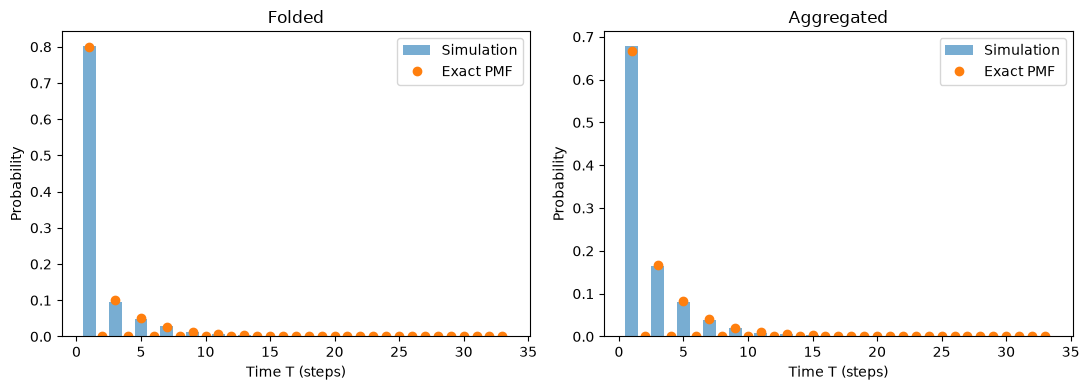

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

states = ["U", "I", "M", "F", "A"]

P = np.array([
    [0, 1/2, 1/2, 0, 0],
    [1/4, 0, 0, 1/2, 1/4],
    [3/4, 0, 0, 0, 1/4],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1]
])

rng = np.random.default_rng(42)

def next_state(current):
    probabilities = P[current]
    u = rng.random()
    cumulative = 0

    for j, probability in enumerate(P[current]):
        cumulative += probability
        if u < cumulative:
            return j

def simulate_chain(start):
    current = start
    time = 0

    while current not in (3, 4): #3 = F, 4 = A
        current = next_state(current)
        time += 1

    return current, time

results = {}

for start in (0, 1, 2):  # U, I, M
    fates = []
    times = []

    for _ in range(10000):
        fate, time = simulate_chain(start)
        fates.append(fate)
        times.append(time)

    results[states[start]] = {
        "fates": np.array(fates),
        "times": np.array(times)
    }

#Calculate the four things the HW asks for
rows = []

for start in ("U", "I", "M"):
    fates = results[start]["fates"]
    times = results[start]["times"]
    h, g, tau_F, tau_A = exact[start]

    rows.append({
        "Start": start,
        "h simulated": (fates == 3).mean(),
        "h exact": h,
        "g simulated": times.mean(),
        "g exact": g,
        "tau_F simulated": times[fates == 3].mean(),
        "tau_F exact": tau_F,
        "tau_A simulated": times[fates == 4].mean(),
        "tau_A exact": tau_A
    })

table = pd.DataFrame(rows).round(3)
print(table.to_string(index=False))

#plot!
for start in ("U", "I", "M"):
    fates = results[start]["fates"]
    times = results[start]["times"]


Q = P[:3, :3]   # moves among U, I, M
R = P[:3, 3:]   # moves from U, I, M to F, A

fates = results["I"]["fates"]
times = results["I"]["times"]
max_time = times.max()
n_values = np.arange(1, max_time + 1)

# Exact P_I(T=n, fate), then divide by P_I(fate)
pmf_F = np.array([
    (np.linalg.matrix_power(Q, n - 1) @ R)[1, 0] / (5/8)
    for n in n_values
])
pmf_A = np.array([
    (np.linalg.matrix_power(Q, n - 1) @ R)[1, 1] / (3/8)
    for n in n_values
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, fate, pmf, title in zip(
    axes,
    (3, 4),
    (pmf_F, pmf_A),
    ("Folded", "Aggregated")
):
    ax.hist(
        times[fates == fate],
        bins=np.arange(0.5, max_time + 1.5, 1),
        density=True,
        alpha=0.6,
        label="Simulation"
    )
    ax.plot(n_values, pmf, "o", label="Exact PMF")
    ax.set(title=title, xlabel="Time T (steps)", ylabel="Probability")
    ax.legend()

plt.tight_layout()
plt.show()

#need to export table:
from matplotlib.backends.backend_pdf import PdfPages
table_fig, ax = plt.subplots(figsize=(16, 3))
ax.axis("off")
ax.table(
    cellText=table.values,
    colLabels=table.columns,
    loc="center",
    cellLoc="center"
)
table_fig.tight_layout()

with PdfPages("hw4_simulation.pdf") as pdf:
    pdf.savefig(table_fig, bbox_inches="tight")
    pdf.savefig(fig, bbox_inches="tight")

plt.close(table_fig)